# Create analysis grid

Create a 1 km analysis grid over the Delhi study area, assign unique grid IDs, and save the grid for downstream population, accessibility, and burden analysis.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    CRS_PROJECTED,
    GRID_SIZE_METERS,
    FILES,
    ensure_project_dirs,
    get_bbox_gdf,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Delhi
BBOX: {'lon_min': 76.8, 'lat_min': 28.4, 'lon_max': 77.4, 'lat_max': 28.95}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/population_20_lon_70_general-v1.5.tif


In [2]:
bbox_gdf = get_bbox_gdf()
bbox_proj = bbox_gdf.to_crs(CRS_PROJECTED)

bbox_proj

,city,geometry
0,Delhi,"POLYGON ((8616128.587 3299498.882, 8616128.587..."


In [3]:
minx, miny, maxx, maxy = bbox_proj.total_bounds

print("Projected bounds:")
print("minx =", minx)
print("miny =", miny)
print("maxx =", maxx)
print("maxy =", maxy)

Projected bounds:
minx = 8549336.89292341
miny = 3299498.8824963216
maxx = 8616128.587399375
maxy = 3369283.6931709866


In [4]:
grid_cells = []

x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(
            box(x, y, x + GRID_SIZE_METERS, y + GRID_SIZE_METERS)
        )
        y += GRID_SIZE_METERS
    x += GRID_SIZE_METERS

grid = gpd.GeoDataFrame(
    {"geometry": grid_cells},
    crs=CRS_PROJECTED
)

grid["grid_id"] = [f"g_{i:05d}" for i in range(len(grid))]
grid = grid[["grid_id", "geometry"]]

print("Number of grid cells before clipping:", len(grid))
grid.head()

Number of grid cells before clipping: 4690


,grid_id,geometry
0,g_00000,"POLYGON ((8550336.893 3299498.882, 8550336.893..."
1,g_00001,"POLYGON ((8550336.893 3300498.882, 8550336.893..."
2,g_00002,"POLYGON ((8550336.893 3301498.882, 8550336.893..."
3,g_00003,"POLYGON ((8550336.893 3302498.882, 8550336.893..."
4,g_00004,"POLYGON ((8550336.893 3303498.882, 8550336.893..."


In [5]:
grid = gpd.overlay(grid, bbox_proj, how="intersection")
grid = grid[["grid_id", "geometry"]].copy()

print("Number of grid cells after clipping:", len(grid))
grid.head()

Number of grid cells after clipping: 4690


,grid_id,geometry
0,g_00000,"POLYGON ((8550336.893 3300498.882, 8550336.893..."
1,g_00001,"POLYGON ((8550336.893 3301498.882, 8550336.893..."
2,g_00002,"POLYGON ((8550336.893 3302498.882, 8550336.893..."
3,g_00003,"POLYGON ((8550336.893 3303498.882, 8550336.893..."
4,g_00004,"POLYGON ((8550336.893 3304498.882, 8550336.893..."


In [6]:
grid["cell_area_m2"] = grid.geometry.area
grid["cell_area_km2"] = grid["cell_area_m2"] / 1_000_000

grid.head()

,grid_id,geometry,cell_area_m2,cell_area_km2
0,g_00000,"POLYGON ((8550336.893 3300498.882, 8550336.893...",1000000.0,1.0
1,g_00001,"POLYGON ((8550336.893 3301498.882, 8550336.893...",1000000.0,1.0
2,g_00002,"POLYGON ((8550336.893 3302498.882, 8550336.893...",1000000.0,1.0
3,g_00003,"POLYGON ((8550336.893 3303498.882, 8550336.893...",1000000.0,1.0
4,g_00004,"POLYGON ((8550336.893 3304498.882, 8550336.893...",1000000.0,1.0


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/02_grid.png


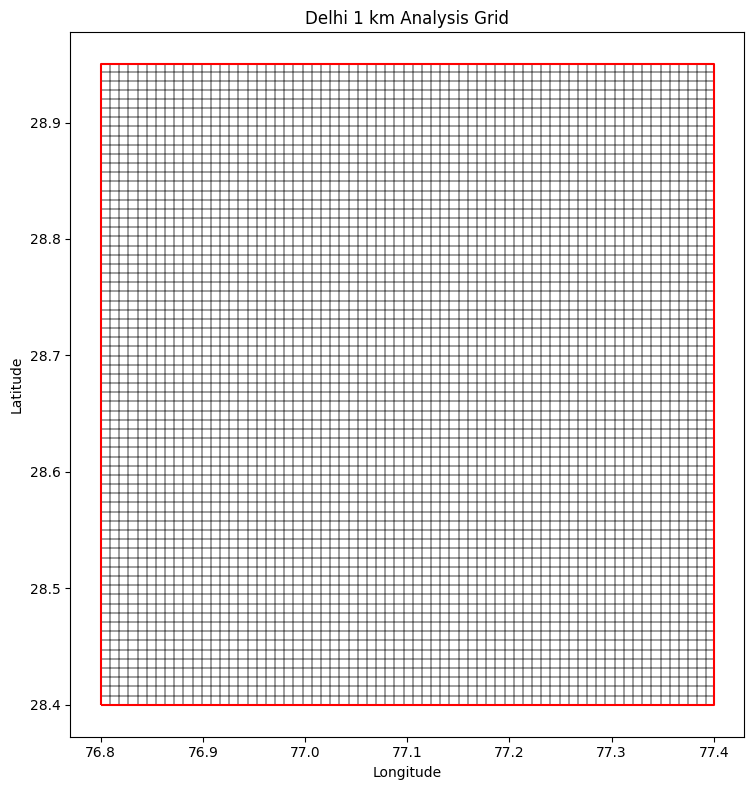

In [7]:
grid_wgs84 = grid.to_crs(CRS_WGS84)

fig, ax = plt.subplots(figsize=(8, 8))
grid_wgs84.boundary.plot(ax=ax, linewidth=0.3, color="black")
bbox_gdf.boundary.plot(ax=ax, linewidth=1.5, color="red")

ax.set_title(f"{CITY_NAME} 1 km Analysis Grid")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "02_grid.png")
plt.show()

In [8]:
grid.to_parquet(FILES["grid"], index=False)
print("Saved grid to:", FILES["grid"])

Saved grid to: /Users/suvo/Projects/urban-healthcare/data/processed/grid.parquet
